### Generate data

In [2]:
# Generating 3D make-moons data

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def make_moons_3d(n_samples=500, noise=0.1):
    # Generate the original 2D make_moons data
    t = np.linspace(0, 2 * np.pi, n_samples)
    x = 1.5 * np.cos(t)
    y = np.sin(t)
    z = np.sin(2 * t)  # Adding a sinusoidal variation in the third dimension
    #在椭圆（参数方程）的基础上添加一个正弦波，使得数据在z轴上有一定的变化
    # Concatenating the positive and negative moons with an offset and noise
    X = np.vstack([np.column_stack([x, y, z]), np.column_stack([-x, y - 1, -z])])
    #通过坐标变换生成了第二个互补的月牙，C1是指np.column_stack([-x, y - 1, -z])，是C0np.column_stack([x, y, z])关于 Y 轴翻转沿 Y 轴，向下平移 1 个单位，-z在高度上做镜像翻转
    y = np.hstack([np.zeros(n_samples), np.ones(n_samples)])

    # Adding Gaussian noise
    X += np.random.normal(scale=noise, size=X.shape)

    return X, y

X_train, y_train = make_moons_3d(n_samples=500, noise=0.2)

# 2. 生成测试集 (500个数据 = 2 * 250)
X_test, y_test = make_moons_3d(n_samples=250, noise=0.2)

print(f"训练集大小: {X_train.shape}, 测试集大小: {X_test.shape}")

训练集大小: (1000, 3), 测试集大小: (500, 3)


### Decision Trees

#### Learning

In [12]:
import numpy as np
#STEP1:用熵来度量Impurity
def calculate_entropy(y):
    p = np.mean(y)
    if p == 0 or p == 1:
        return 0
    else:
        return - (p * np.log2(p) + (1 - p) * np.log2(1 - p))


In [ ]:
#STEP2:寻找切分点（以下是全局搜索最优切分点）（这个是直接tap的版本）
def find_split(X, y):
    entropy = float('inf')
    best_feature = None
    best_threshold = None

    n_samples, n_features = X.shape
    #轮流测试X/Y/Z三个维度的切分点，寻找最优切分点
    for f in range(n_features):
        thresholds = np.unique(X[:, f])#核心优化：np.unique 找出这一列所有不重复的取值作为“候选切分点”
        for thr in thresholds:
            left_indices = X[:, f] <= thr
            right_indices = X[:, f] > thr
            #优化，避免Not a Number (NaN)问题
            if len(y[left_indices]) == 0 or len(y[right_indices]) == 0:
                continue

            left_entropy = calculate_entropy(y[left_indices])
            right_entropy = calculate_entropy(y[right_indices])
            weighted_entropy = (len(y[left_indices]) * left_entropy + len(y[right_indices]) * right_entropy) / n_samples

            if weighted_entropy < entropy:
                entropy = weighted_entropy
                best_feature = f   # 记录下当前的获胜者
                best_threshold = thr # 记录下当前的获胜者

    return best_feature, best_threshold

In [ ]:
#STEP2
def split_dataset(X, y, feature_idx, threshold):
    # 1. 创建一个布尔型遮罩 (mask)，判断第 feature_idx 列是否小于等于 threshold
    mask = X[:, feature_idx] <= threshold
    # 2. 根据 mask 提取左半部分数据
    X_left = X[mask]
    y_left = y[mask]
    # 3. 根据 ~mask (取反) 提取右半部分数据
    X_right = X[~mask]
    y_right = y[~mask]
    # 4. 返回 X_left, y_left, X_right, y_right
    return X_left, y_left, X_right, y_right
def calculate_information_gain(X, y, feature_idx, threshold):
    # 1. 计算切分前的熵
    parent_entropy = calculate_entropy(y)
    
    # 2. 调用你写的 split_dataset 进行切分
    X_l, y_l, X_r, y_r = split_dataset(X, y, feature_idx, threshold)
    
    # 3. 如果切分后有一边是空的，说明这一剪刀没意义，增益为 0
    if len(y_l) == 0 or len(y_r) == 0:
        return 0
    
    # 4. 计算左右两边的权重 (子集样本数 / 总样本数)
    weight_l = len(y_l) / len(y)
    weight_r = len(y_r) / len(y)

    # 5. 计算切分后的加权熵 (Weighted Child Entropy)
    child_entropy = weight_l * calculate_entropy(y_l) + weight_r * calculate_entropy(y_r)
    
    # 6. 返回 信息增益
    return parent_entropy - child_entropy



In [ ]:
#如果只在给定数据范围里面二分法尝试会不会还是收敛很慢呢，尝试只在特征的 10%、20% ... 90% 这些位置（分位数）切 9 刀试试
#thresholds = np.percentile(X[:, feature], np.linspace(0, 100, 10))

#STEP2:寻找切分点（以下是全局搜索最优切分点）（这个是直接tap的版本）
def find_split(X, y):
    entropy = float('inf')
    best_feature = None
    best_threshold = None

    n_samples, n_features = X.shape
    for f in range(n_features):
        thresholds = np.percentile(X[:, f], np.linspace(0, 100, 10))
        for thr in thresholds:
            left_indices = X[:, f] <= thr
            right_indices = X[:, f] > thr

            if len(y[left_indices]) == 0 or len(y[right_indices]) == 0:
                continue

            left_entropy = calculate_entropy(y[left_indices])
            right_entropy = calculate_entropy(y[right_indices])
            weighted_entropy = (len(y[left_indices]) * left_entropy + len(y[right_indices]) * right_entropy) / n_samples

            if weighted_entropy < entropy:
                entropy = weighted_entropy
                best_feature = f
                best_threshold = thr

    return best_feature, best_threshold

In [9]:
#STEP3：递归build_tree
def build_tree(X, y, depth, max_depth):
    #如果 y 里面全是一类 (纯度为 0)，就直接停下
    if len(np.unique(y)) == 1:
        return int(y[0])
    #如果达到了最大深度
    if depth >= max_depth:
        # 返回这一堆人里占多数的那个类 (提示: np.mean(y) >= 0.5 则返回 1)
        return 1 if np.mean(y) >= 0.5 else 0
    #寻找切分点
    feature_idx, threshold = find_split(X, y)
    #如果X全都一样，停下
    if feature_idx is None:
        return 1 if np.mean(y) >= 0.5 else 0

    left_mask = X[:, feature_idx] <= threshold
    right_mask = ~left_mask

    #用字典来存储
    node = {
        'feature_idx': feature_idx,
        'threshold': threshold,
        'left': None,
        'right': None
    }

    #递归构建左右子树
    node['left'] = build_tree(X[left_mask], y[left_mask], depth + 1, max_depth)
    node['right'] = build_tree(X[right_mask], y[right_mask], depth + 1, max_depth)

    return node

In [10]:
# 生成训练集
X_train, y_train = make_moons_3d(n_samples=500, noise=0.2)
# 训练模型（构建字典树）
my_tree = build_tree(X_train, y_train, depth=0, max_depth=5)

c:\Users\LENION\anaconda3\envs\PRML\lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\LENION\anaconda3\envs\PRML\lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [13]:
import numpy as np
#STEP1:用熵来度量Impurity
def calculate_entropy(y):
    p = np.mean(y)
    if p == 0 or p == 1:
        return 0
    else:
        return - (p * np.log2(p) + (1 - p) * np.log2(1 - p))
#STEP2:寻找切分点
#thresholds = np.percentile(X[:, feature], np.linspace(0, 100, 10))
def find_split(X, y):
    entropy = float('inf')
    best_feature = None
    best_threshold = None

    n_samples, n_features = X.shape
    
    for f in range(n_features):
        thresholds = np.unique(X[:, f])
        for thr in thresholds:
            left_indices = X[:, f] <= thr
            right_indices = X[:, f] > thr
            
            if len(y[left_indices]) == 0 or len(y[right_indices]) == 0:
                continue

            left_entropy = calculate_entropy(y[left_indices])
            right_entropy = calculate_entropy(y[right_indices])
            weighted_entropy = (len(y[left_indices]) * left_entropy + len(y[right_indices]) * right_entropy) / n_samples

            if weighted_entropy < entropy:
                entropy = weighted_entropy
                best_feature = f
                best_threshold = thr

    return best_feature, best_threshold
#STEP3：递归build_tree
def build_tree(X, y, depth, max_depth):
    #如果 y 里面全是一类 (纯度为 0)，就直接停下
    if len(np.unique(y)) == 1:
        return int(y[0])
    #如果达到了最大深度
    if depth >= max_depth:
        # 返回这一堆人里占多数的那个类 (提示: np.mean(y) >= 0.5 则返回 1)
        return 1 if np.mean(y) >= 0.5 else 0
    #寻找切分点
    feature_idx, threshold = find_split(X, y)
    #如果X全都一样，停下
    if feature_idx is None:
        return 1 if np.mean(y) >= 0.5 else 0

    left_mask = X[:, feature_idx] <= threshold
    right_mask = ~left_mask

    #用字典来存储
    node = {
        'feature_idx': feature_idx,
        'threshold': threshold,
        'left': None,
        'right': None
    }

    #递归构建左右子树
    node['left'] = build_tree(X[left_mask], y[left_mask], depth + 1, max_depth)
    node['right'] = build_tree(X[right_mask], y[right_mask], depth + 1, max_depth)

    return node
# 生成训练集
X_train, y_train = make_moons_3d(n_samples=500, noise=0.2)
# 训练模型（构建字典树）
my_tree = build_tree(X_train, y_train, depth=0, max_depth=5)

In [14]:
def print_tree(node, spacing=""):
    """
    递归打印树的结构
    """
    # 如果是叶子节点（即返回的是 0 或 1）
    if not isinstance(node, dict):
        print(spacing + f"┗━ 预测结果: {'类别 C1' if node == 1 else '类别 C0'}")
        return

    # 打印当前节点的决策逻辑
    features = ['X轴', 'Y轴', 'Z轴']
    print(spacing + f"┳━ [维度: {features[node['feature_idx']]} | 阈值: {node['threshold']:.4f}]")

    # 递归打印左子树
    print(spacing + "┣━ 左子树 (<= 阈值):")
    print_tree(node['left'], spacing + "┃  ")

    # 递归打印右子树
    print(spacing + "┗━ 右子树 (> 阈值):")
    print_tree(node['right'], spacing + "   ")

# 打印你刚刚生成的树
print_tree(my_tree)

┳━ [维度: Y轴 | 阈值: -1.3312]
┣━ 左子树 (<= 阈值):
┃  ┗━ 预测结果: 类别 C1
┗━ 右子树 (> 阈值):
   ┳━ [维度: Y轴 | 阈值: 0.3072]
   ┣━ 左子树 (<= 阈值):
   ┃  ┳━ [维度: Y轴 | 阈值: -0.6492]
   ┃  ┣━ 左子树 (<= 阈值):
   ┃  ┃  ┳━ [维度: X轴 | 阈值: 1.2992]
   ┃  ┃  ┣━ 左子树 (<= 阈值):
   ┃  ┃  ┃  ┳━ [维度: X轴 | 阈值: -1.2214]
   ┃  ┃  ┃  ┣━ 左子树 (<= 阈值):
   ┃  ┃  ┃  ┃  ┗━ 预测结果: 类别 C1
   ┃  ┃  ┃  ┗━ 右子树 (> 阈值):
   ┃  ┃  ┃     ┗━ 预测结果: 类别 C0
   ┃  ┃  ┗━ 右子树 (> 阈值):
   ┃  ┃     ┳━ [维度: Z轴 | 阈值: -1.1174]
   ┃  ┃     ┣━ 左子树 (<= 阈值):
   ┃  ┃     ┃  ┗━ 预测结果: 类别 C0
   ┃  ┃     ┗━ 右子树 (> 阈值):
   ┃  ┃        ┗━ 预测结果: 类别 C1
   ┃  ┗━ 右子树 (> 阈值):
   ┃     ┳━ [维度: X轴 | 阈值: 1.2047]
   ┃     ┣━ 左子树 (<= 阈值):
   ┃     ┃  ┳━ [维度: X轴 | 阈值: -0.9952]
   ┃     ┃  ┣━ 左子树 (<= 阈值):
   ┃     ┃  ┃  ┗━ 预测结果: 类别 C0
   ┃     ┃  ┗━ 右子树 (> 阈值):
   ┃     ┃     ┗━ 预测结果: 类别 C1
   ┃     ┗━ 右子树 (> 阈值):
   ┃        ┳━ [维度: Z轴 | 阈值: 0.1286]
   ┃        ┣━ 左子树 (<= 阈值):
   ┃        ┃  ┗━ 预测结果: 类别 C0
   ┃        ┗━ 右子树 (> 阈值):
   ┃           ┗━ 预测结果: 类别 C0
   ┗━ 右子树 (> 阈值):
      ┳━

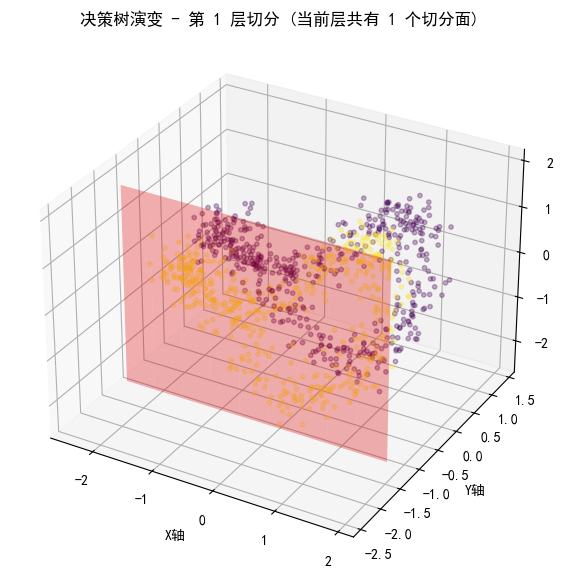

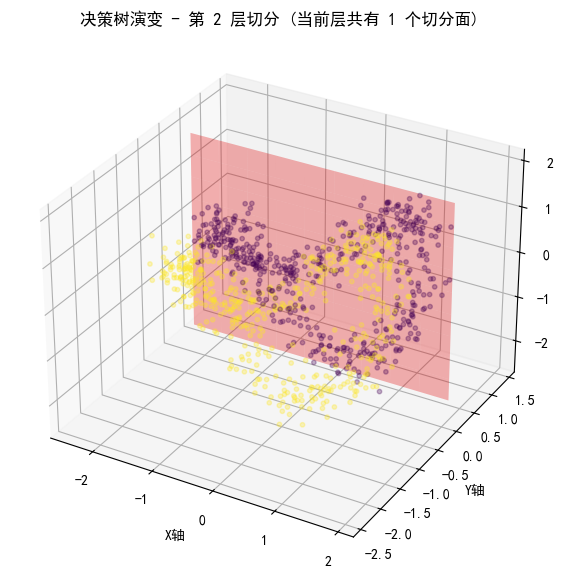

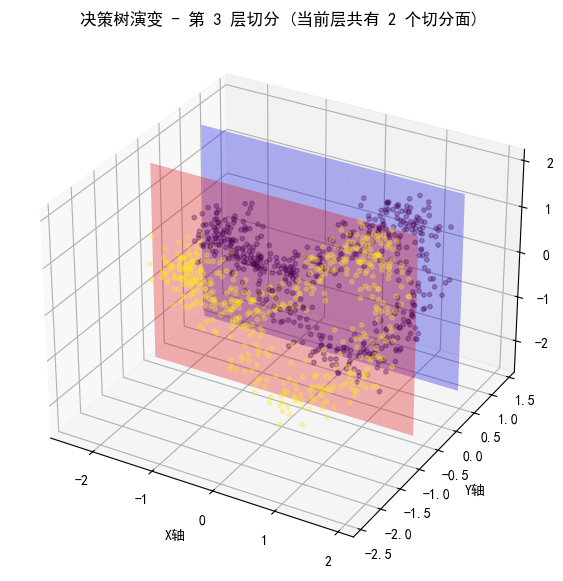

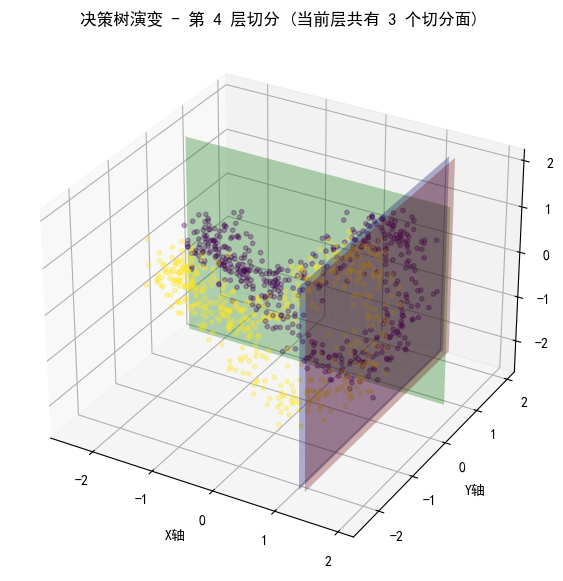

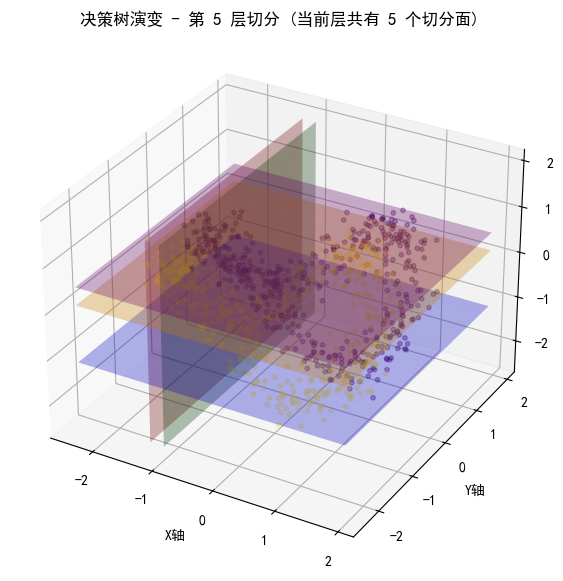

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False 

def get_nodes_at_depth(node, target_depth, current_depth=0):
    """递归获取某一深度的所有决策节点"""
    if not isinstance(node, dict):
        return []
    if current_depth == target_depth:
        return [node]
    
    nodes = []
    nodes.extend(get_nodes_at_depth(node['left'], target_depth, current_depth + 1))
    nodes.extend(get_nodes_at_depth(node['right'], target_depth, current_depth + 1))
    return nodes

def plot_tree_evolution(X, y, tree, max_display_depth=3):
    """依次展示每一层深度的切分情况"""
    
    for d in range(max_display_depth):
        nodes = get_nodes_at_depth(tree, d)
        if not nodes:
            break
            
        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(111, projection='3d')
        
        # 1. 绘制原始数据点
        ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='viridis', alpha=0.3, s=10)
        
        # 2. 绘制该层的所有切分平面
        for i, node in enumerate(nodes):
            f_idx = node['feature_idx']
            thr = node['threshold']
            
            # 设置平面的显示范围
            r = np.linspace(X.min(), X.max(), 10)
            D1, D2 = np.meshgrid(r, r)
            
            color_list = ['red', 'blue', 'green', 'orange', 'purple']
            c = color_list[i % len(color_list)]
            
            if f_idx == 0: # X轴切分
                ax.plot_surface(np.full_like(D1, thr), D1, D2, color=c, alpha=0.3)
            elif f_idx == 1: # Y轴切分
                ax.plot_surface(D1, np.full_like(D1, thr), D2, color=c, alpha=0.3)
            else: # Z轴切分
                ax.plot_surface(D1, D2, np.full_like(D1, thr), color=c, alpha=0.3)
        
        ax.set_xlabel('X轴')
        ax.set_ylabel('Y轴')
        ax.set_zlabel('Z轴')
        ax.set_title(f'决策树演变 - 第 {d+1} 层切分 (当前层共有 {len(nodes)} 个切分面)')
        plt.show()

# 调用函数查看变化
plot_tree_evolution(X_train, y_train, my_tree, max_display_depth=5)

In [ ]:
def predict_one(node, x):
    # 逻辑：如果是数字就返回；如果是字典就对比 x[f_idx] 和 threshold
    if not isinstance(node, dict):
        return node
    
    if x[node['feature_idx']] <= node['threshold']:
        return predict_one(node['left'], x)
    else:
        return predict_one(node['right'], x)

# 1. 生成测试集 (按照作业要求，2*250=500个点)
X_test, y_test = make_moons_3d(n_samples=250, noise=0.2)

# 2. 进行预测
y_pred = np.array([predict_one(my_tree, x) for x in X_test])

# 3. 计算准确率
accuracy = np.mean(y_pred == y_test)
print(f"决策树在测试集上的准确率: {accuracy * 100:.2f}%")

决策树在测试集上的准确率: 87.60%


#### Final Code

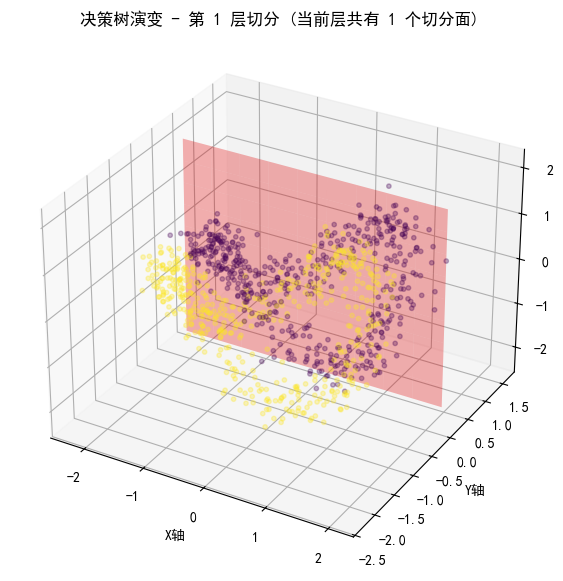

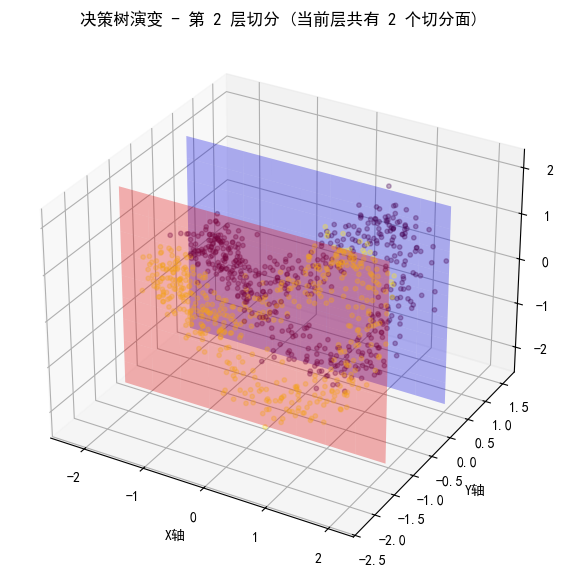

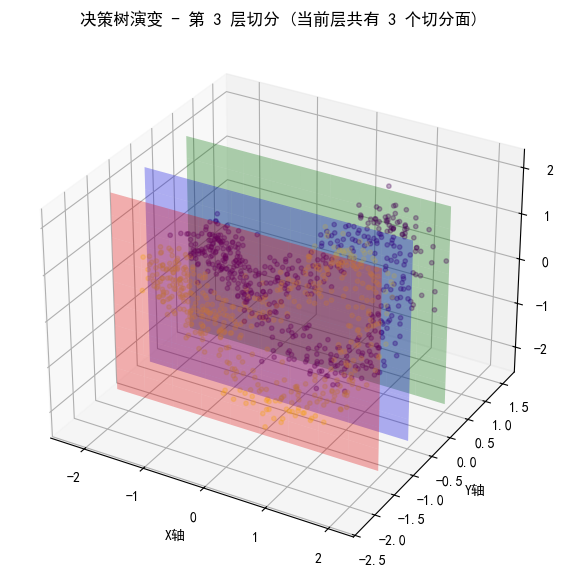

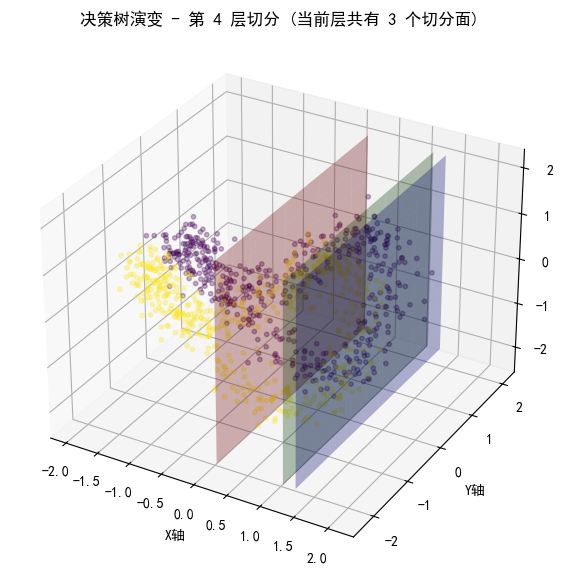

决策树在测试集上的准确率: 80.40%


In [16]:
import numpy as np
#STEP1:用熵来度量Impurity
def calculate_entropy(y):
    p = np.mean(y)
    if p == 0 or p == 1:
        return 0
    else:
        return - (p * np.log2(p) + (1 - p) * np.log2(1 - p))
#STEP2:寻找切分点
#thresholds = np.percentile(X[:, feature], np.linspace(0, 100, 10))
def find_split(X, y):
    entropy = float('inf')
    best_feature = None
    best_threshold = None

    n_samples, n_features = X.shape
    
    for f in range(n_features):
        thresholds = np.unique(X[:, f])
        for thr in thresholds:
            left_indices = X[:, f] <= thr
            right_indices = X[:, f] > thr
            
            if len(y[left_indices]) == 0 or len(y[right_indices]) == 0:
                continue

            left_entropy = calculate_entropy(y[left_indices])
            right_entropy = calculate_entropy(y[right_indices])
            weighted_entropy = (len(y[left_indices]) * left_entropy + len(y[right_indices]) * right_entropy) / n_samples

            if weighted_entropy < entropy:
                entropy = weighted_entropy
                best_feature = f
                best_threshold = thr

    return best_feature, best_threshold
#STEP3：递归build_tree
def build_tree(X, y, depth, max_depth):
    #如果 y 里面全是一类 (纯度为 0)，就直接停下
    if len(np.unique(y)) == 1:
        return int(y[0])
    #如果达到了最大深度
    if depth >= max_depth:
        # 返回这一堆人里占多数的那个类 (提示: np.mean(y) >= 0.5 则返回 1)
        return 1 if np.mean(y) >= 0.5 else 0
    #寻找切分点
    feature_idx, threshold = find_split(X, y)
    #如果X全都一样，停下
    if feature_idx is None:
        return 1 if np.mean(y) >= 0.5 else 0

    left_mask = X[:, feature_idx] <= threshold
    right_mask = ~left_mask

    #用字典来存储
    node = {
        'feature_idx': feature_idx,
        'threshold': threshold,
        'left': None,
        'right': None
    }

    #递归构建左右子树
    node['left'] = build_tree(X[left_mask], y[left_mask], depth + 1, max_depth)
    node['right'] = build_tree(X[right_mask], y[right_mask], depth + 1, max_depth)

    return node

# 生成训练集
X_train, y_train = make_moons_3d(n_samples=500, noise=0.2)
# 训练模型（构建字典树）
my_tree = build_tree(X_train, y_train, depth=0, max_depth=4)
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False 

def get_nodes_at_depth(node, target_depth, current_depth=0):
    """递归获取某一深度的所有决策节点"""
    if not isinstance(node, dict):
        return []
    if current_depth == target_depth:
        return [node]
    
    nodes = []
    nodes.extend(get_nodes_at_depth(node['left'], target_depth, current_depth + 1))
    nodes.extend(get_nodes_at_depth(node['right'], target_depth, current_depth + 1))
    return nodes

def plot_tree_evolution(X, y, tree, max_display_depth):
    """依次展示每一层深度的切分情况"""
    
    for d in range(max_display_depth):
        nodes = get_nodes_at_depth(tree, d)
        if not nodes:
            break
            
        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(111, projection='3d')
        
        # 1. 绘制原始数据点
        ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='viridis', alpha=0.3, s=10)
        
        # 2. 绘制该层的所有切分平面
        for i, node in enumerate(nodes):
            f_idx = node['feature_idx']
            thr = node['threshold']
            
            # 设置平面的显示范围
            r = np.linspace(X.min(), X.max(), 10)
            D1, D2 = np.meshgrid(r, r)
            
            color_list = ['red', 'blue', 'green', 'orange', 'purple']
            c = color_list[i % len(color_list)]
            
            if f_idx == 0: # X轴切分
                ax.plot_surface(np.full_like(D1, thr), D1, D2, color=c, alpha=0.3)
            elif f_idx == 1: # Y轴切分
                ax.plot_surface(D1, np.full_like(D1, thr), D2, color=c, alpha=0.3)
            else: # Z轴切分
                ax.plot_surface(D1, D2, np.full_like(D1, thr), color=c, alpha=0.3)
        
        ax.set_xlabel('X轴')
        ax.set_ylabel('Y轴')
        ax.set_zlabel('Z轴')
        ax.set_title(f'决策树演变 - 第 {d+1} 层切分 (当前层共有 {len(nodes)} 个切分面)')
        plt.show()

# 调用函数查看变化
plot_tree_evolution(X_train, y_train, my_tree, max_display_depth=4)

def predict_one(node, x):
    # 逻辑：如果是数字就返回；如果是字典就对比 x[f_idx] 和 threshold
    if not isinstance(node, dict):
        return node
    
    if x[node['feature_idx']] <= node['threshold']:
        return predict_one(node['left'], x)
    else:
        return predict_one(node['right'], x)

# 1. 生成测试集 (按照作业要求，2*250=500个点)
X_test, y_test = make_moons_3d(n_samples=250, noise=0.2)

# 2. 进行预测
y_pred = np.array([predict_one(my_tree, x) for x in X_test])

# 3. 计算准确率
accuracy = np.mean(y_pred == y_test)
print(f"决策树在测试集上的准确率: {accuracy * 100:.2f}%")

In [20]:
import numpy as np

def calculate_gini(y, weights):
    total_w = np.sum(weights)
    if total_w == 0: 
        return 0
    
    p1 = np.sum(weights[y == 1]) / total_w
    p0 = 1 - p1
    
    return 1 - (p0**2 + p1**2)

def find_split_Gini(X, y, weights):
    best_gini = float('inf')
    best_f = None
    best_thr = None
    
    n_samples, n_features = X.shape
    total_weight = np.sum(weights)
    
    for f in range(n_features):
        thresholds = np.unique(X[:, f])
        
        for thr in thresholds:
            left_mask = X[:, f] <= thr
            right_mask = ~left_mask
            
            if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                continue

            gini_l = calculate_gini(y[left_mask], weights[left_mask])
            gini_r = calculate_gini(y[right_mask], weights[right_mask])
            
            w_gini = (np.sum(weights[left_mask]) * gini_l + 
                      np.sum(weights[right_mask]) * gini_r) / total_weight

            if w_gini < best_gini:
                best_gini = w_gini
                best_f = f
                best_thr = thr

    return best_f, best_thr

def build_tree_Gini(X, y, weights, depth, max_depth):

    if len(np.unique(y)) == 1:
        return int(y[0])

    if depth >= max_depth:
        return 1 if np.sum(weights[y == 1]) >= np.sum(weights[y == 0]) else 0

    f_idx, thr = find_split_Gini(X, y, weights)
    
    if f_idx is None:
        return 1 if np.sum(weights[y == 1]) >= np.sum(weights[y == 0]) else 0

    left_mask = X[:, f_idx] <= thr
    right_mask = ~left_mask

    return {
        'feature_idx': f_idx,
        'threshold': thr,
        'left': build_tree_Gini(X[left_mask], y[left_mask], weights[left_mask], depth + 1, max_depth),
        'right': build_tree_Gini(X[right_mask], y[right_mask], weights[right_mask], depth + 1, max_depth)
    }

X_train, y_train = make_moons_3d(n_samples=500, noise=0.2)
weights = np.ones(len(y_train)) / len(y_train)

my_gini_tree = build_tree_Gini(X_train, y_train, weights, depth=0, max_depth=4)

def predict_Gini(tree, X):
    def _p(node, x):
        if not isinstance(node, dict): return node
        if x[node['feature_idx']] <= node['threshold']:
            return _p(node['left'], x)
        else:
            return _p(node['right'], x)
    return np.array([_p(tree, sample) for sample in X])

X_test, y_test = make_moons_3d(n_samples=250, noise=0.2)
preds = predict_Gini(my_gini_tree, X_test)
print(f"基于 Gini 指数的决策树准确率: {np.mean(preds == y_test) * 100:.2f}%")

基于 Gini 指数的决策树准确率: 79.40%


In [21]:
import pandas as pd
# 设定多个种子进行多次实验
seeds = [1, 10, 50, 100, 200]
results = []

for s in seeds:
    np.random.seed(s)

    X_train, y_train = make_moons_3d(n_samples=500, noise=0.2)
    X_test, y_test = make_moons_3d(n_samples=250, noise=0.2)
    weights = np.ones(len(y_train)) / len(y_train)

    tree_entropy = build_tree(X_train, y_train, depth=0, max_depth=4)
    preds_e = np.array([predict_one(tree_entropy, x) for x in X_test])
    acc_e = np.mean(preds_e == y_test)

    tree_gini = build_tree_Gini(X_train, y_train, weights, depth=0, max_depth=4)
    preds_g = predict_Gini(tree_gini, X_test)
    acc_g = np.mean(preds_g == y_test)

    results.append({
        'Seed': s,
        'Entropy_Acc': acc_e,
        'Gini_Acc': acc_g
    })

df = pd.DataFrame(results)

summary = df.describe().loc[['mean', 'std', 'min', 'max']]

print("### 各随机种子下的实验结果 ###")
print(df.to_string(index=False))
print("\n### 统计汇总 ###")
print(summary)

### 各随机种子下的实验结果 ###
 Seed  Entropy_Acc  Gini_Acc
    1        0.720     0.718
   10        0.714     0.798
   50        0.744     0.806
  100        0.742     0.806
  200        0.814     0.814

### 统计汇总 ###
            Seed  Entropy_Acc  Gini_Acc
mean   72.200000     0.746800  0.788400
std    81.450599     0.039815  0.039759
min     1.000000     0.714000  0.718000
max   200.000000     0.814000  0.814000


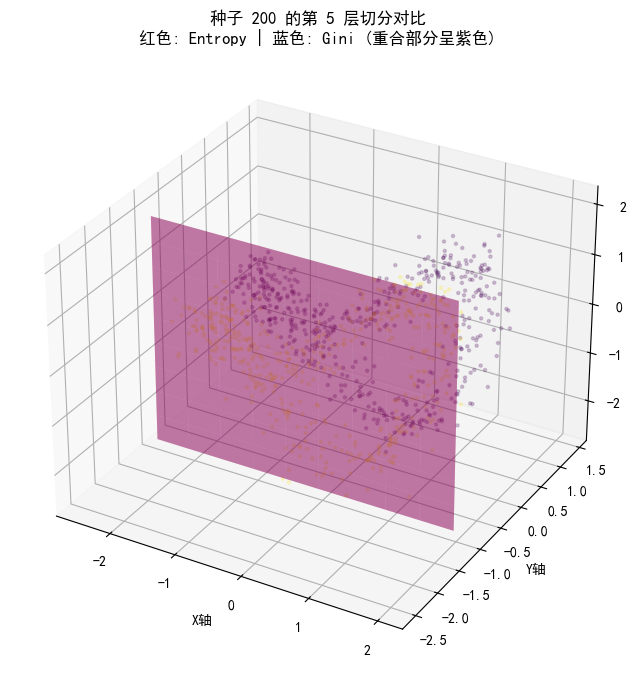

In [26]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- 1. 定义辅助函数：获取树在特定深度的所有切分点 ---
def get_nodes_at_depth_fixed(node, target_depth, current_depth=4):
    if not isinstance(node, dict):
        return []
    if current_depth == target_depth:
        return [node]
    nodes = []
    nodes.extend(get_nodes_at_depth_fixed(node['left'], target_depth, current_depth + 1))
    nodes.extend(get_nodes_at_depth_fixed(node['right'], target_depth, current_depth + 1))
    return nodes

# --- 2. 绘图对比 ---
def plot_final_comparison(X, y, t_entropy, t_gini, depth=4):
    fig = plt.figure(figsize=(14, 8))
    
    # 这里的 X, y 分别对应你循环中最后的 X_train, y_train
    # tree_entropy 和 tree_gini 对应最后的模型
    
    ax = fig.add_subplot(111, projection='3d')
    
    # 绘制原始数据点
    ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='viridis', alpha=0.2, s=5)
    
    # 获取特定深度的切分节点
    nodes_e = get_nodes_at_depth_fixed(t_entropy, depth)
    nodes_g = get_nodes_at_depth_fixed(t_gini, depth)
    
    # 准备切分平面网格
    r = np.linspace(X.min(), X.max(), 10)
    D1, D2 = np.meshgrid(r, r)

    # 绘制 Entropy 版的切分面 (红色)
    for node in nodes_e:
        f, t = node['feature_idx'], node['threshold']
        if f == 0: ax.plot_surface(np.full_like(D1, t), D1, D2, color='red', alpha=0.4)
        elif f == 1: ax.plot_surface(D1, np.full_like(D1, t), D2, color='red', alpha=0.4)
        else: ax.plot_surface(D1, D2, np.full_like(D1, t), color='red', alpha=0.4)

    # 绘制 Gini 版的切分面 (蓝色)
    for node in nodes_g:
        f, t = node['feature_idx'], node['threshold']
        if f == 0: ax.plot_surface(np.full_like(D1, t), D1, D2, color='blue', alpha=0.2)
        elif f == 1: ax.plot_surface(D1, np.full_like(D1, t), D2, color='blue', alpha=0.2)
        else: ax.plot_surface(D1, D2, np.full_like(D1, t), color='blue', alpha=0.2)

    ax.set_title(f"种子 {seeds[-1]} 的第 {depth+1} 层切分对比\n红色: Entropy | 蓝色: Gini (重合部分呈紫色)")
    ax.set_xlabel('X轴'); ax.set_ylabel('Y轴'); ax.set_zlabel('Z轴')
    plt.show()

# 运行绘图
plot_final_comparison(X_train, y_train, tree_entropy, tree_gini, depth=4)

### AdaBoost + Decision Trees

In [ ]:
def adaboost_train(X, y, T=20, max_depth=1):
    n = len(y)
    #y也要映射到 {-1, +1}
    y_signed = np.where(y == 1, 1, -1)
    w = np.ones(n) / n
    
    models = []
    alphas = []
    
    for t in range(T):
        #训练弱学习器DT
        tree = build_tree_Gini(X, y, w, depth=0, max_depth=max_depth)
        pred = predict_Gini(tree, X)
        
        #映射到 {-1, +1}
        pred_signed = np.where(pred == 1, 1, -1)

        incorrect = (pred != y)
        epsilon = np.sum(w * incorrect)

        epsilon = np.clip(epsilon, 1e-10, 1 - 1e-10)#关键修复：避免 epsilon 为 0 或 1 导致 alpha 无穷大或负无穷大
        alpha = 0.5 * np.log((1 - epsilon) / epsilon)

        w = w * np.exp(-alpha * y_signed * pred_signed)
        w = w / np.sum(w)
        
        models.append(tree)
        alphas.append(alpha)

        print(f"Round {t+1}: epsilon={epsilon:.4f}, alpha={alpha:.4f}")
    
    return models, alphas

In [33]:
def adaboost_predict(X, models, alphas):
    final_pred = np.zeros(X.shape[0])
    
    for tree, alpha in zip(models, alphas):
        pred = predict_Gini(tree, X)
        pred_signed = np.where(pred == 1, 1, -1)
        final_pred += alpha * pred_signed

    final_pred = np.sign(final_pred)

    return np.where(final_pred == 1, 1, 0)

In [34]:
models, alphas = adaboost_train(X_train, y_train, T=20, max_depth=4)
preds_boost = adaboost_predict(X_test, models, alphas)

print(f"AdaBoost 准确率: {np.mean(preds_boost == y_test) * 100:.2f}%")

Round 1: epsilon=0.1700, alpha=0.7928
Round 2: epsilon=0.1071, alpha=1.0604
Round 3: epsilon=0.1060, alpha=1.0664
Round 4: epsilon=0.1249, alpha=0.9733
Round 5: epsilon=0.1426, alpha=0.8970
Round 6: epsilon=0.2035, alpha=0.6823
Round 7: epsilon=0.1916, alpha=0.7199
Round 8: epsilon=0.1826, alpha=0.7493
Round 9: epsilon=0.1355, alpha=0.9268
Round 10: epsilon=0.2010, alpha=0.6901
Round 11: epsilon=0.1816, alpha=0.7529
Round 12: epsilon=0.1230, alpha=0.9821
Round 13: epsilon=0.1730, alpha=0.7823
Round 14: epsilon=0.1897, alpha=0.7260
Round 15: epsilon=0.1860, alpha=0.7381
Round 16: epsilon=0.1297, alpha=0.9519
Round 17: epsilon=0.1269, alpha=0.9645
Round 18: epsilon=0.3733, alpha=0.2590
Round 19: epsilon=0.3208, alpha=0.3751
Round 20: epsilon=0.2483, alpha=0.5539
AdaBoost 准确率: 97.20%


Round 1: epsilon=0.2920, alpha=0.4428
Round 1: epsilon=0.2920, alpha=0.4428
Round 2: epsilon=0.2186, alpha=0.6369
Round 1: epsilon=0.2920, alpha=0.4428
Round 2: epsilon=0.2186, alpha=0.6369
Round 3: epsilon=0.3331, alpha=0.3471
Round 1: epsilon=0.2920, alpha=0.4428
Round 2: epsilon=0.2186, alpha=0.6369
Round 3: epsilon=0.3331, alpha=0.3471
Round 4: epsilon=0.3777, alpha=0.2497
Round 1: epsilon=0.2920, alpha=0.4428
Round 2: epsilon=0.2186, alpha=0.6369
Round 3: epsilon=0.3331, alpha=0.3471
Round 4: epsilon=0.3777, alpha=0.2497
Round 5: epsilon=0.4017, alpha=0.1991
Round 1: epsilon=0.2920, alpha=0.4428
Round 2: epsilon=0.2186, alpha=0.6369
Round 3: epsilon=0.3331, alpha=0.3471
Round 4: epsilon=0.3777, alpha=0.2497
Round 5: epsilon=0.4017, alpha=0.1991
Round 6: epsilon=0.4179, alpha=0.1658
Round 1: epsilon=0.2920, alpha=0.4428
Round 2: epsilon=0.2186, alpha=0.6369
Round 3: epsilon=0.3331, alpha=0.3471
Round 4: epsilon=0.3777, alpha=0.2497
Round 5: epsilon=0.4017, alpha=0.1991
Round 6: eps

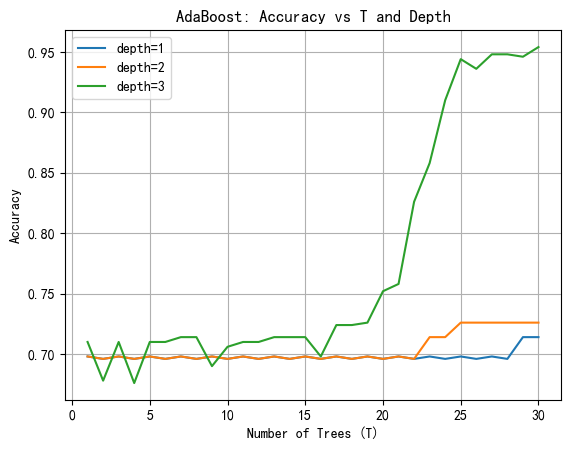

In [35]:
import numpy as np
import matplotlib.pyplot as plt

X_train, y_train = make_moons_3d(n_samples=500, noise=0.2)
X_test, y_test = make_moons_3d(n_samples=250, noise=0.2)

T_values = list(range(1, 31))   # 树的数量
depth_values = [1, 2, 3]        # 不同深度

results = {}
for depth in depth_values:
    acc_list = []
    
    for T in T_values:
        models, alphas = adaboost_train(
            X_train, y_train,
            T=T,
            max_depth=depth
        )
        
        preds = adaboost_predict(X_test, models, alphas)
        acc = np.mean(preds == y_test)
        acc_list.append(acc)
    
    results[depth] = acc_list

plt.figure()

for depth in depth_values:
    plt.plot(T_values, results[depth], label=f"depth={depth}")

plt.xlabel("Number of Trees (T)")
plt.ylabel("Accuracy")
plt.title("AdaBoost: Accuracy vs T and Depth")
plt.legend()
plt.grid()

plt.show()

### SVM(Three Different Kernel Functions)

Linear: 68.80%
  support_.shape = (612,)
Polynomial (degree=1): 68.80%
  support_.shape = (616,)
Polynomial (degree=2): 75.80%
  support_.shape = (684,)
Polynomial (degree=3): 88.20%
  support_.shape = (403,)
Polynomial (degree=4): 76.40%
  support_.shape = (533,)
Polynomial (degree=5): 88.60%
  support_.shape = (365,)
Polynomial (degree=6): 79.20%
  support_.shape = (497,)
Polynomial (degree=7): 87.80%
  support_.shape = (364,)
Polynomial (degree=8): 78.40%
  support_.shape = (482,)
Polynomial (degree=9): 86.60%
  support_.shape = (370,)
Polynomial (degree=10): 77.60%
  support_.shape = (477,)
RBF (gamma=0.1): 85.00%
  support_.shape = (529,)
RBF (gamma=1): 98.20%
  support_.shape = (166,)
RBF (gamma=10): 98.20%
  support_.shape = (419,)
RBF (gamma=100): 93.40%
  support_.shape = (984,)
RBF (gamma=1000): 60.40%
  support_.shape = (1000,)
RBF (gamma=10000): 50.20%
  support_.shape = (1000,)
RBF (gamma=100000): 50.00%
  support_.shape = (1000,)
Sigmoid: 49.60%
  support_.shape = (536,)


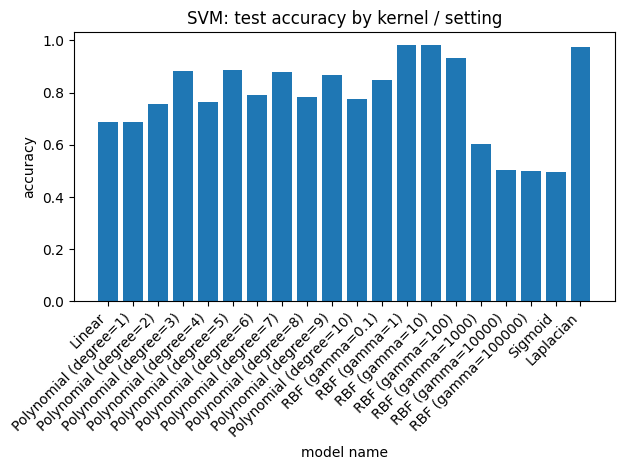

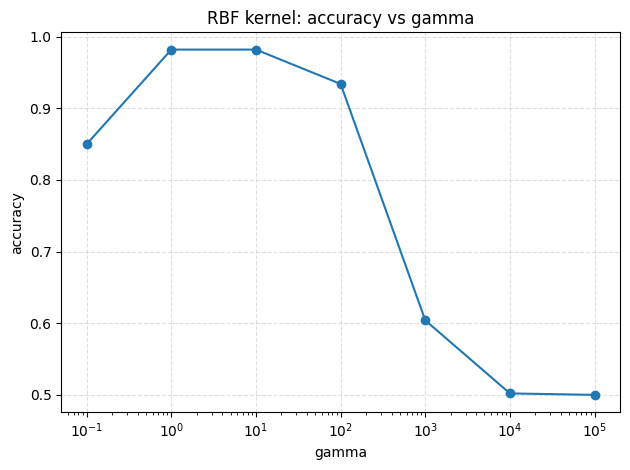

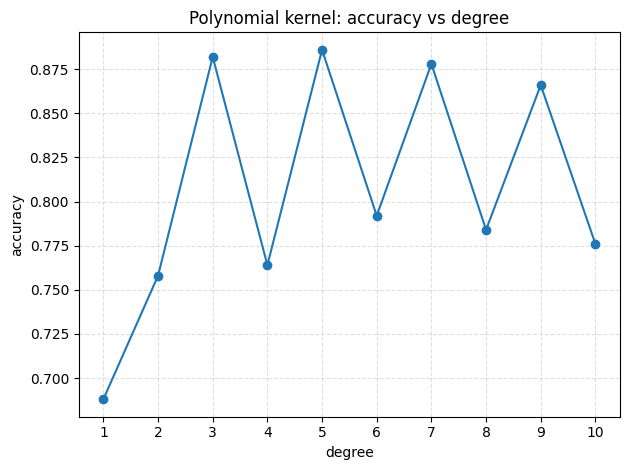

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import laplacian_kernel

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

X_train, y_train = make_moons_3d(n_samples=500, noise=0.2)
X_test, y_test = make_moons_3d(n_samples=250, noise=0.2)

results = {}
support_shapes = {}
model_order = []


def fit_report(name, estimator):
    estimator.fit(X_train, y_train)
    y_pred = estimator.predict(X_test)
    acc = float(accuracy_score(y_test, y_pred))
    results[name] = acc
    support_shapes[name] = estimator.support_.shape
    model_order.append(name)
    print(f"{name}: {acc * 100:.2f}%")
    print(f"  support_.shape = {estimator.support_.shape}")
    return estimator


# 1) Linear
fit_report("Linear", SVC(kernel="linear", C=1, random_state=RANDOM_SEED))

# 2) Polynomial (multiple degrees)
for degree in (1,2, 3,4,5,6,7,8,9,10):
    fit_report(
        f"Polynomial (degree={degree})",
        SVC(kernel="poly", degree=degree, C=1, random_state=RANDOM_SEED),
    )

# 3) RBF (multiple gamma) 
for gamma in (0.1, 1, 10,100,1000,10000,100000):
    fit_report(
        f"RBF (gamma={gamma})",
        SVC(kernel="rbf", C=1, gamma=gamma, random_state=RANDOM_SEED),
    )

# 4) Sigmoid
fit_report(
    "Sigmoid",
    SVC(kernel="sigmoid", C=1, gamma="scale", coef0=1, random_state=RANDOM_SEED),
)

# 5) Laplacian (custom pairwise kernel; sklearn callable signature K(X, Y))
fit_report(
    "Laplacian",
    SVC(kernel=laplacian_kernel, C=1, random_state=RANDOM_SEED),
)

best_name = max(results, key=results.get)
best_acc = results[best_name]
print()
print(f"Best Model: {best_name}")
print(f"Accuracy: {best_acc * 100:.2f}%")

plt.figure()
plt.bar(model_order, [results[m] for m in model_order])
plt.ylabel("accuracy")
plt.xlabel("model name")
plt.title("SVM: test accuracy by kernel / setting")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

rbf_gammas = [0.1, 1, 10,100,1000,10000,100000]
rbf_names = [f"RBF (gamma={g})" for g in rbf_gammas]
rbf_accs = [results[n] for n in rbf_names]

plt.figure()
plt.plot(rbf_gammas, rbf_accs, marker="o")
plt.xscale("log")
plt.xlabel("gamma")
plt.ylabel("accuracy")
plt.title("RBF kernel: accuracy vs gamma")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

poly_degrees = [1,2, 3, 4,5,6,7,8,9,10]
poly_names = [f"Polynomial (degree={d})" for d in poly_degrees]
poly_accs = [results[n] for n in poly_names]

plt.figure()
plt.plot(poly_degrees, poly_accs, marker="o")
plt.xlabel("degree")
plt.ylabel("accuracy")
plt.title("Polynomial kernel: accuracy vs degree")
plt.xticks(poly_degrees)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
